<a href="https://colab.research.google.com/github/Hala-sala7/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales
- Auther : Hala Salah

##

## Project Overview

## Load and Inspect Data

In [ ]:
from google.colab import drive
drive.mount("/content/Data")
fname = "/content/Data/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv"
import pandas as pd
df = pd.read_csv(fname)

Drive already mounted at /content/Data; to attempt to forcibly remount, call drive.mount("/content/Data", force_remount=True).


In [ ]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Clean Data

In [ ]:
df.shape

(8523, 12)

In [ ]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [ ]:
duplicated_raws=df.duplicated()
duplicated_raws

,0
0,False
1,False
2,False
3,False
4,False
...,...
8518,False
8519,False
8520,False
8521,False


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,False,False,False,False,False,False,False,False,False,False,False,False
8519,False,False,False,False,False,False,False,False,True,False,False,False
8520,False,False,False,False,False,False,False,False,False,False,False,False
8521,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
null_sums = df.isna().sum()
null_sums

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
null_persent = null_sums/len(df) *100
null_persent

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


<Axes: >

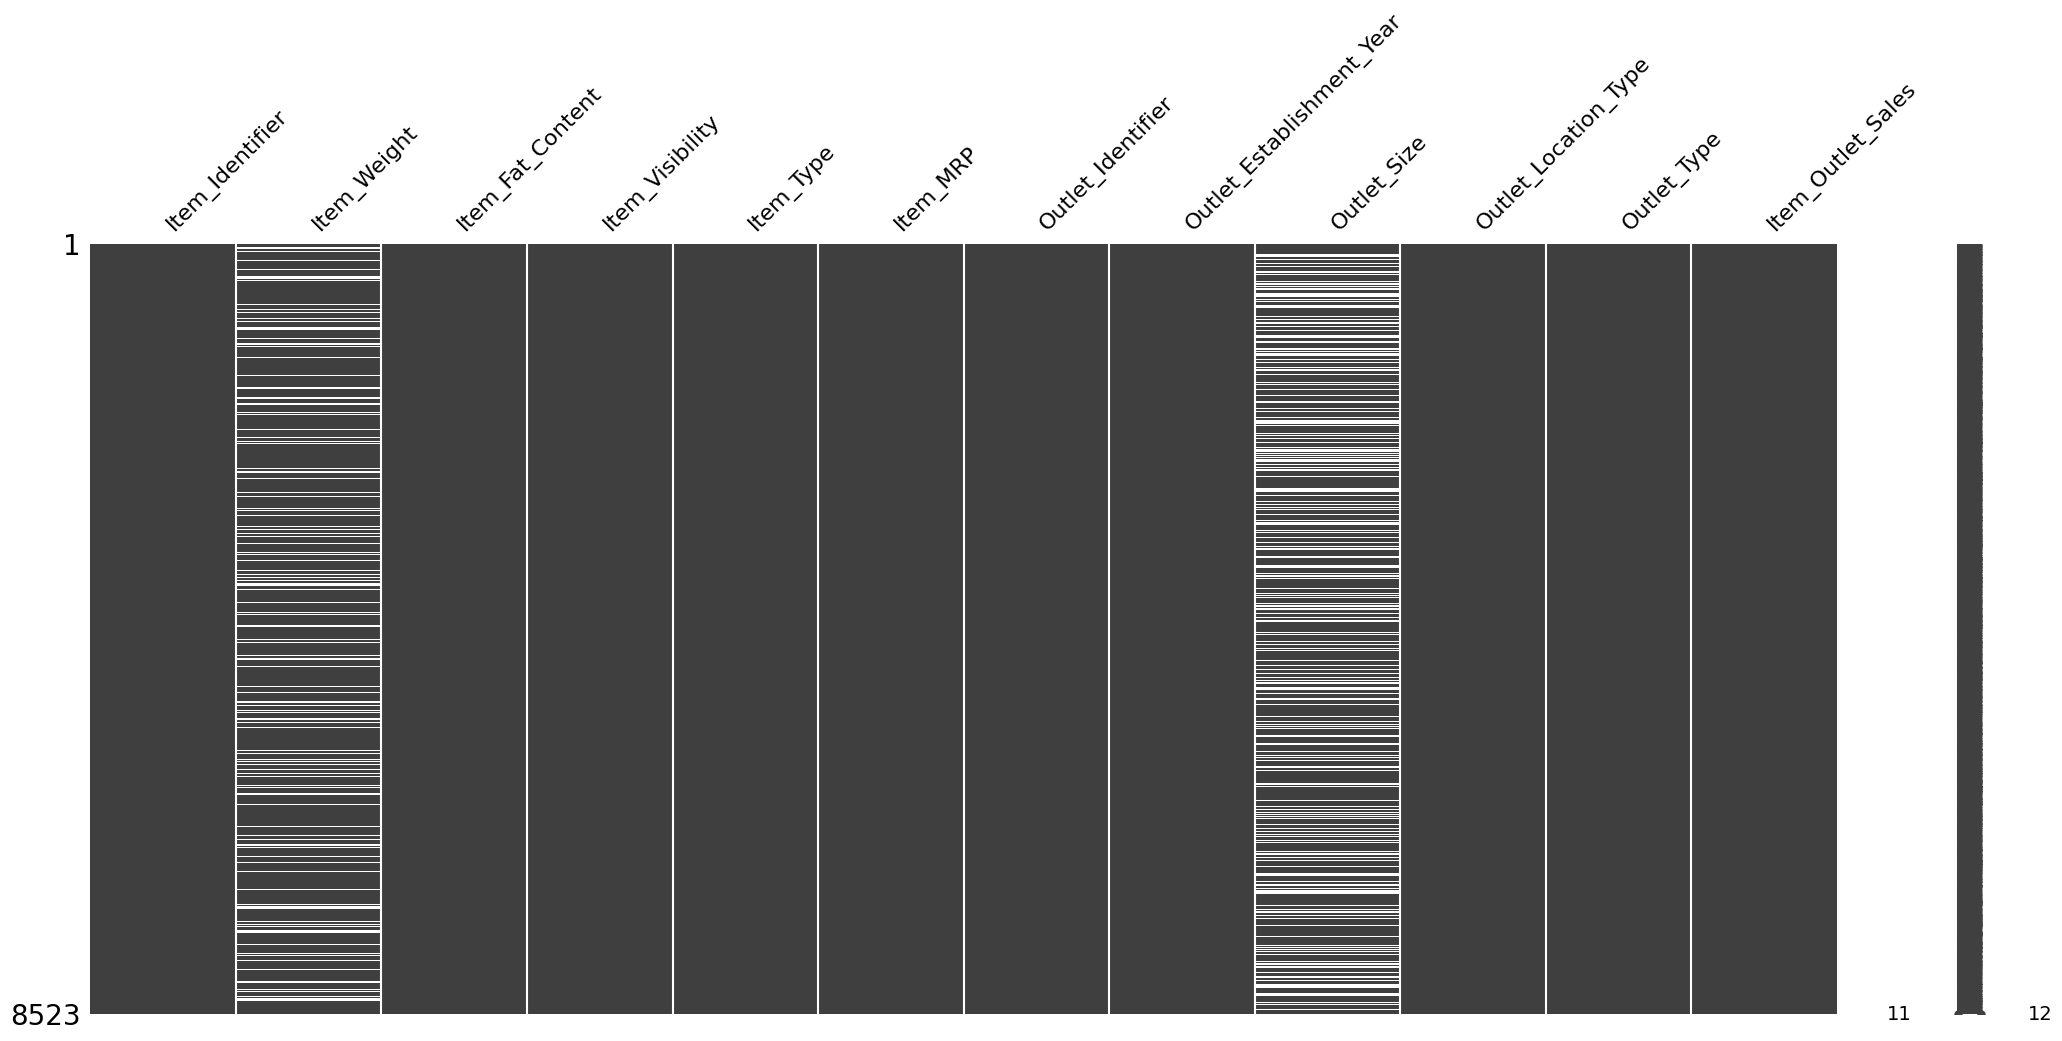

In [ ]:
import missingno as msno
msno.matrix(df)

In [ ]:
object_columns = df.select_dtypes('object').columns
object_columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [ ]:
number_columns = df.select_dtypes('number').columns
number_columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
df[object_columns].isna().sum()

,0
Item_Identifier,0
Item_Fat_Content,0
Item_Type,0
Outlet_Identifier,0
Outlet_Size,2410
Outlet_Location_Type,0
Outlet_Type,0


In [ ]:
df[number_columns].isna().sum()

,0
Item_Weight,1463
Item_Visibility,0
Item_MRP,0
Outlet_Establishment_Year,0
Item_Outlet_Sales,0


In [ ]:
df['Outlet_Size'] =df['Outlet_Size'].fillna("MISSING")

df["Outlet_Size"].value_counts()

,count
Outlet_Size,
Medium,2793
MISSING,2410
Small,2388
High,932


In [ ]:
df['Item_Weight'] = df['Item_Weight'].fillna(-1)
df['Item_Weight'].value_counts()

,count
Item_Weight,
12.150,103
17.600,101
13.650,89
11.800,86
15.100,86
...,...
16.350,1
6.780,1
6.115,1


In [ ]:
df['Item_Weight'].isna().sum()

np.int64(0)

In [ ]:
for col in object_columns:
  print(f'value Counts for {col}')
  print(df[col].value_counts())
  print('\n')

value Counts for Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


value Counts for Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


value Counts for Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


value Counts for Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013

In [ ]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [ ]:
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({"Low Fat": "low fat",
    "LF": "low fat",
     "reg":"Regular"})
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
low fat,5517
Regular,3006


In [ ]:
df[number_columns].describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8519.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.875420,0.066132,140.992782,1997.831867,2181.288914
std,4.646098,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.785000,0.026989,93.826500,1987.000000,834.247400
50%,12.650000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Exploratory Data Analysis

In [ ]:
number_columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sorted(df['Item_Visibility'].unique())

[np.float64(0.0),
 np.float64(0.003574698),
 np.float64(0.003589104),
 np.float64(0.003597678),
 np.float64(0.003599378),
 np.float64(0.003606726),
 np.float64(0.003612411),
 np.float64(0.005209791),
 np.float64(0.005230786),
 np.float64(0.005234153),
 np.float64(0.005235143),
 np.float64(0.005243282),
 np.float64(0.005264755),
 np.float64(0.005448005),
 np.float64(0.00547348),
 np.float64(0.005474515),
 np.float64(0.005485618),
 np.float64(0.005496816),
 np.float64(0.005505481),
 np.float64(0.005525913),
 np.float64(0.00552947),
 np.float64(0.005530516),
 np.float64(0.005539114),
 np.float64(0.005547386),
 np.float64(0.005557062),
 np.float64(0.005561538),
 np.float64(0.005561798),
 np.float64(0.005583951),
 np.float64(0.005611367),
 np.float64(0.005620213),
 np.float64(0.005638944),
 np.float64(0.005661669),
 np.float64(0.005677876),
 np.float64(0.005935001),
 np.float64(0.005949644),
 np.float64(0.005958918),
 np.float64(0.005962753),
 np.float64(0.005963881),
 np.float64(0.00597362

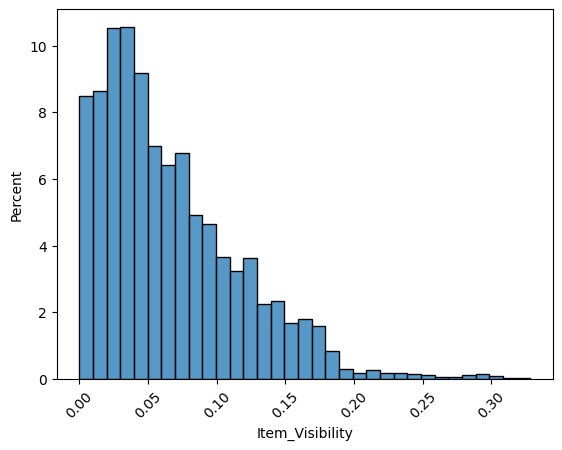

In [ ]:
ax = sns.histplot(data=df, x='Item_Visibility', binwidth=0.01, stat='percent')
ax.ticklabel_format(style='plain')
ax.tick_params(axis='x', rotation=45)



The histogram shows that most products have low item visibility in the store, with values concentrated between approximately 0.01 and 0.08. This indicates that most products occupy a small portion of the display area, while only a few products have high visibility in the store.


In [ ]:
df['Item_Visibility'].describe()

,Item_Visibility
count,8523.000000
mean,0.066132
std,0.051598
min,0.000000
25%,0.026989
50%,0.053931
75%,0.094585
max,0.328391


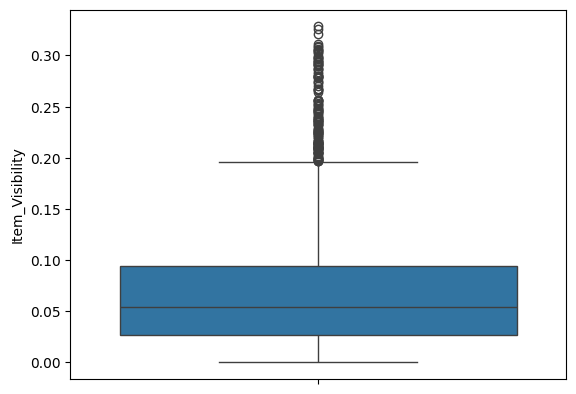

In [ ]:
ax=sns.boxplot(data=df,y="Item_Visibility")

The boxplot shows that most products have low item visibility, with a median around 0.05. Most values fall between approximately 0.03 and 0.09, indicating that the majority of products occupy a small portion of the shelf display. There are several high outliers, suggesting that a small number of products receive much higher visibility compared to the rest.

In [ ]:
df.select_dtypes('object').nunique()

,0
Item_Identifier,1559
Item_Fat_Content,2
Item_Type,16
Outlet_Identifier,10
Outlet_Size,4
Outlet_Location_Type,3
Outlet_Type,4


In [ ]:
df['Outlet_Identifier'].value_counts()

,count
Outlet_Identifier,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555


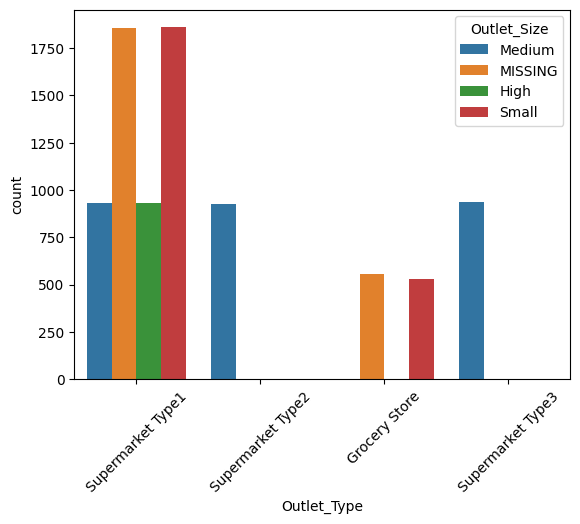

In [ ]:
ax = sns.countplot(data=df, x="Outlet_Type", hue="Outlet_Size")
ax.tick_params(axis='x', rotation=45)

The countplot shows the distribution of outlet sizes across different outlet types. Supermarket Type1 appears in all outlet sizes (Small, Medium, and High) and also contains many missing size values, indicating it is the most diverse and common outlet type. Supermarket Type2 and Supermarket Type3 appear only with Medium outlet size, suggesting these supermarket types are typically medium-sized stores. Grocery Stores are mainly associated with Small outlet sizes and some missing values.

In [ ]:
core = df.corr(numeric_only=True)
core

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.010285,0.026743,-0.011246,0.012962
Item_Visibility,-0.010285,1.000000,-0.001315,-0.074834,-0.128625
Item_MRP,0.026743,-0.001315,1.000000,0.005020,0.567574
Outlet_Establishment_Year,-0.011246,-0.074834,0.005020,1.000000,-0.049135
Item_Outlet_Sales,0.012962,-0.128625,0.567574,-0.049135,1.000000


<Axes: >

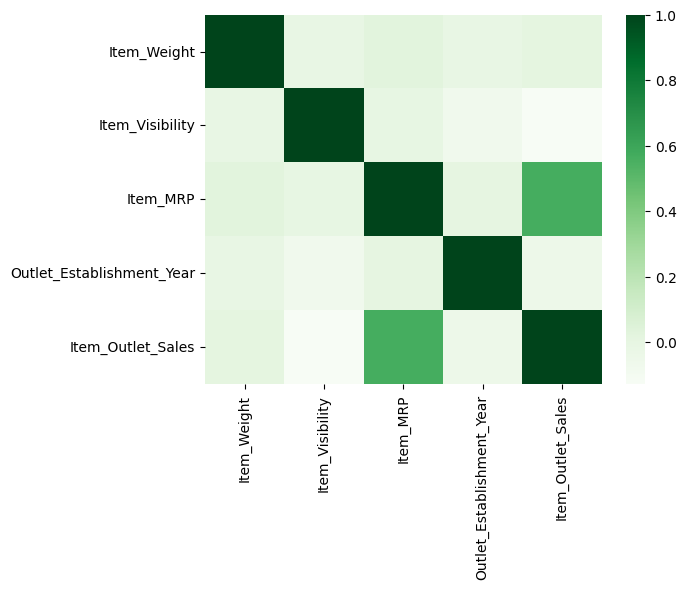

In [ ]:
sns.heatmap(core,cmap="Greens")

The positive correlation between Item_MRP and Item_Outlet_Sales occurs because higher priced products tend to generate higher sales revenue.

In [ ]:
df['Item_Outlet_Sales'].value_counts().sort_index(ascending=False)

,count
Item_Outlet_Sales,
13086.9648,1
12117.5600,1
11445.1020,1
10993.6896,1
10306.5840,1
...,...
36.6190,2
35.2874,1
34.6216,1


In [ ]:
df['Item_Outlet_Sales'].describe()

,Item_Outlet_Sales
count,8523.000000
mean,2181.288914
std,1706.499616
min,33.290000
25%,834.247400
50%,1794.331000
75%,3101.296400
max,13086.964800


Text(0.5, 1.0, 'Distribution of Item Outlet Sales')

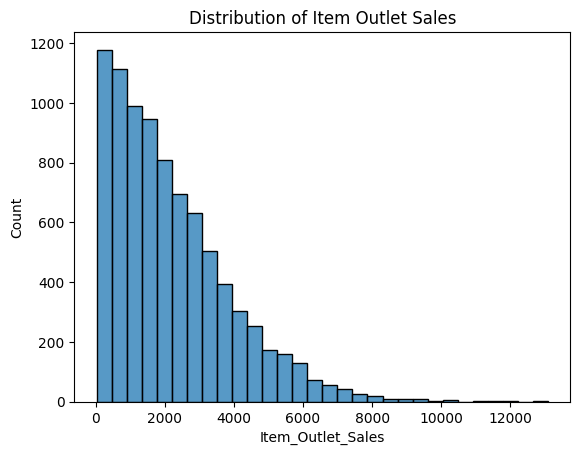

In [ ]:
ax = sns.histplot(data=df, x="Item_Outlet_Sales", bins=30)

plt.title("Distribution of Item Outlet Sales")

The histogram shows that Item_Outlet_Sales are right-skewed. Most products generate relatively low to moderate sales, while a small number of products achieve very high sales values, creating a long right tail in the distribution.


In [ ]:
df['Item_Outlet_Sales'].isna().sum()

np.int64(0)

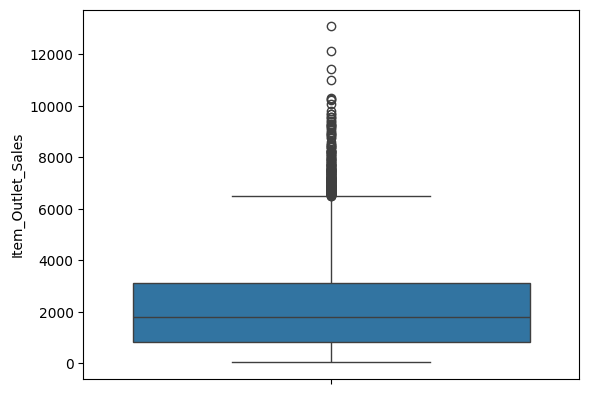

In [ ]:
ax=sns.boxplot(data=df,y='Item_Outlet_Sales')

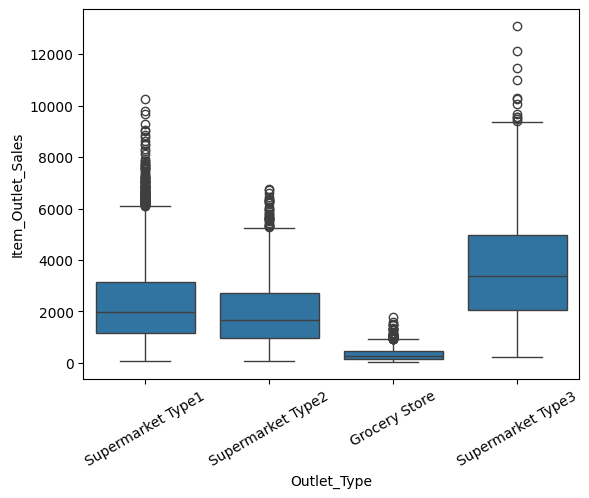

In [ ]:
ax=sns.boxplot(data=df, x="Outlet_Type", y="Item_Outlet_Sales")
ax=ax.tick_params(axis='x', rotation=30)


The boxplot shows that Supermarket Type3 has the highest sales distribution among outlet types. Supermarket Type1 and Type2 have moderate sales, while Grocery Stores show the lowest sales values. Several high outliers indicate that some products generate significantly higher sales than others

## Feature Inspection